## Sentiment Analysis & Helpfulness Prediction

This Notebook is the final stage of our text mining pipeline. It focuses exclusively on text-based analysis to answer one core question:

**"What linguistic patterns makes a review useful?"**

**Chapter Structure:**

| Section | What We Do |
|---|---|
| 5.1 | Compute sentiment scores using TextBlob |
| 5.2 | Predict helpfulness using text features |
| 5.3 | Analyze what makes reviews helpful |
| 5.4 | Export text features for integration |

**Important design decision:**
This chapter uses TEXT FEATURES ONLY, no behavioral data like playtime or number of reviews. This branch focuses purely on what the text tells us. Behavioral features will be integrated in the next phase of the project.

**Text features used:**
- TF-IDF vectors from review_cleaned_sentiment
- Review length (word_count_cleaned)
- Vocabulary richness (TTR)
- Sentiment polarity and subjectivity (TextBlob)
- Topic membership (lda_topic, nmf_topic from Notebook 4)

**Target:** is_helpful (1 if votes_helpful ≥ 1, else 0)

### Load Dependencies & Notebook 4 Output

We load all libraries needed for modeling and the dataset saved at the end of Chapter 4, which contains cleaned text, behavioral features, and topic assignments from both LDA and NMF models.

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    f1_score,
    accuracy_score
)
from scipy.sparse import hstack, csr_matrix
from textblob import TextBlob
from tqdm import tqdm
tqdm.pandas()

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

df = pd.read_parquet('../data/steam_text_mining_nb4.parquet')

print(f"Rows    : {len(df):,}")
print(f"Columns : {df.columns.tolist()}")

Rows    : 919,083
Columns : ['review', 'recommended', 'votes_helpful', 'written_during_early_access', 'author.playtime_at_review', 'author.num_reviews', 'app_name', 'app_id', 'playtime_hours', 'review_cleaned', 'review_cleaned_sentiment', 'word_count_raw', 'word_count_cleaned', 'word_count_conservative', 'ttr', 'is_helpful', 'lda_topic', 'lda_topic_label', 'nmf_topic', 'nmf_topic_label']


## 5.1 Sentiment Analysis Using TextBlob

TextBlob is a library that reads raw text and assigns two scores to each review:

- **Polarity** (−1 to +1):
  How positive or negative the text is.
  −1 = very negative, 0 = neutral, +1 = very positive

- **Subjectivity** (0 to 1):
  How opinion-based the text is.
  0 = very factual, 1 = very opinionated

We compute these scores for every review and use them as text-derived features in our prediction model.

We use the raw `review` column (not preprocessed text) because TextBlob is designed to read natural language.


In [60]:
print("Computing sentiment scores...")

df['polarity'] = df['review'].progress_apply(lambda x: TextBlob(str(x)).sentiment.polarity)

df['subjectivity'] = df['review'].progress_apply(lambda x: TextBlob(str(x)).sentiment.subjectivity)

print(f"\nsentiment scores computed for {len(df):,} reviews")

Computing sentiment scores...


100%|██████████| 919083/919083 [01:35<00:00, 9667.90it/s] 


sentiment scores computed for 919,083 reviews


### 5.1a Do Positive and Negative Reviews Differ in Sentiment?

We compare polarity and subjectivity between positive (recommended = True) and negative (recommended = False) reviews.

If our preprocessing worked correctly, positive reviews should show higher polarity than negative ones. This validates that our text features carry genuine sentiment signal for downstream modeling.

In [61]:
print("Sentiment Scores by Recommendation\n")
sentiment_summary = df.groupby('recommended').agg(
    mean_polarity     = ('polarity',     'mean'),
    median_polarity   = ('polarity',     'median'),
    mean_subjectivity = ('subjectivity', 'mean'),
    review_count      = ('review',       'count')
).round(4)
sentiment_summary.index = ['Negative', 'Positive']
print(sentiment_summary)

Sentiment Scores by Recommendation

          mean_polarity  median_polarity  mean_subjectivity  review_count
Negative        -0.0829          -0.0467             0.4624        114849
Positive         0.1494           0.1267             0.4780        804234


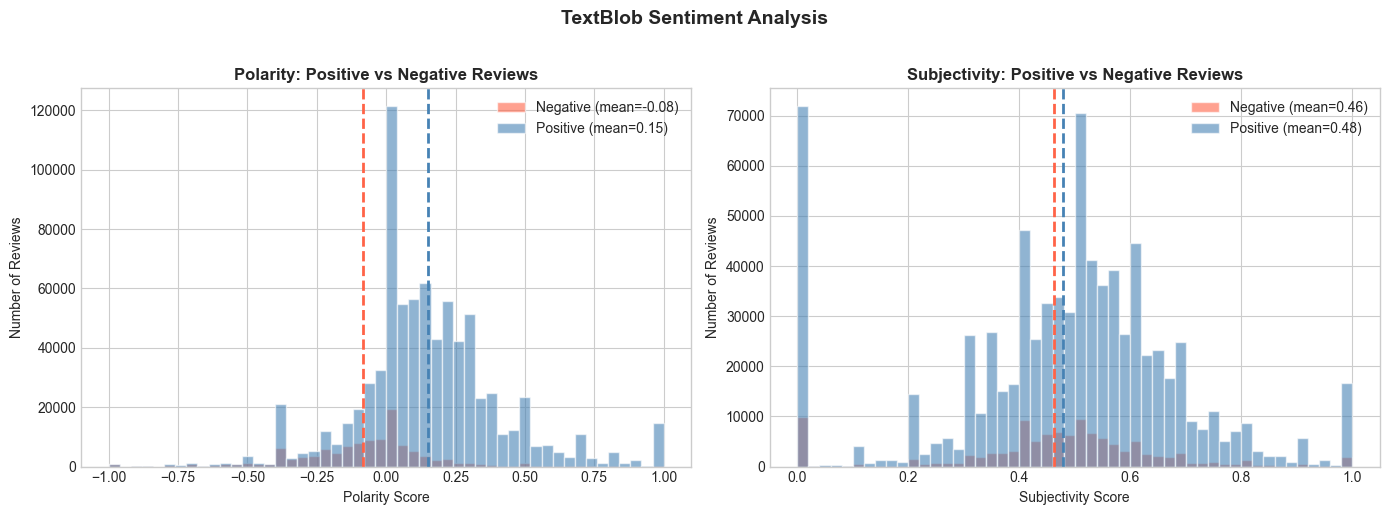

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Polarity
pos = df[df['recommended'] == True]['polarity']
neg = df[df['recommended'] == False]['polarity']

axes[0].hist(neg, bins=50, alpha=0.6, color='tomato', label=f'Negative (mean={neg.mean():.2f})', edgecolor='white')
axes[0].hist(pos, bins=50, alpha=0.6, color='steelblue', label=f'Positive (mean={pos.mean():.2f})', edgecolor='white')
axes[0].axvline(neg.mean(), color='tomato', linestyle='--', linewidth=2)
axes[0].axvline(pos.mean(), color='steelblue', linestyle='--', linewidth=2)
axes[0].set_title('Polarity: Positive vs Negative Reviews', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Polarity Score')
axes[0].set_ylabel('Number of Reviews')
axes[0].legend()

# Subjectivity
pos_s = df[df['recommended'] == True]['subjectivity']
neg_s = df[df['recommended'] == False]['subjectivity']

axes[1].hist(neg_s, bins=50, alpha=0.6, color='tomato', label=f'Negative (mean={neg_s.mean():.2f})', edgecolor='white')
axes[1].hist(pos_s, bins=50, alpha=0.6, color='steelblue', label=f'Positive (mean={pos_s.mean():.2f})', edgecolor='white')
axes[1].axvline(neg_s.mean(), color='tomato', linestyle='--', linewidth=2)
axes[1].axvline(pos_s.mean(), color='steelblue',linestyle='--', linewidth=2)
axes[1].set_title('Subjectivity: Positive vs Negative Reviews', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Subjectivity Score')
axes[1].set_ylabel('Number of Reviews')
axes[1].legend()

plt.suptitle('TextBlob Sentiment Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.1b Sentiment by Topic

We examine how sentiment varies across the NMF topics discovered in Notebook 4. Topics with low mean polarity indicate themes associated with negative experiences. Topics with high mean polarity indicate themes associated with positive experiences.

Mean Polarity by Topic
nmf_topic_label
Top Rated RPG & Strategy Games          0.2832
Version & Sequel Comparisons            0.2171
Story, Gameplay & Soundtrack Quality    0.1989
Overall Game Quality & Immersion        0.1858
Game Franchise & Series Reviews         0.1460
Social & Multiplayer Experience         0.1325
Value for Money & Pricing               0.1261
Modding Community & Workshop            0.1226
First Impressions & Game World          0.1090
Remakes & Simulator Experiences         0.0994
Technical Issues & Fix Requests         0.0959
Game Longevity & Long-term Play         0.0866
Sandbox & Souls-like Games              0.0579
Purchase Advice & DLC Concerns          0.0511
Game Difficulty & Skill Progression     0.0405
Name: polarity, dtype: float64


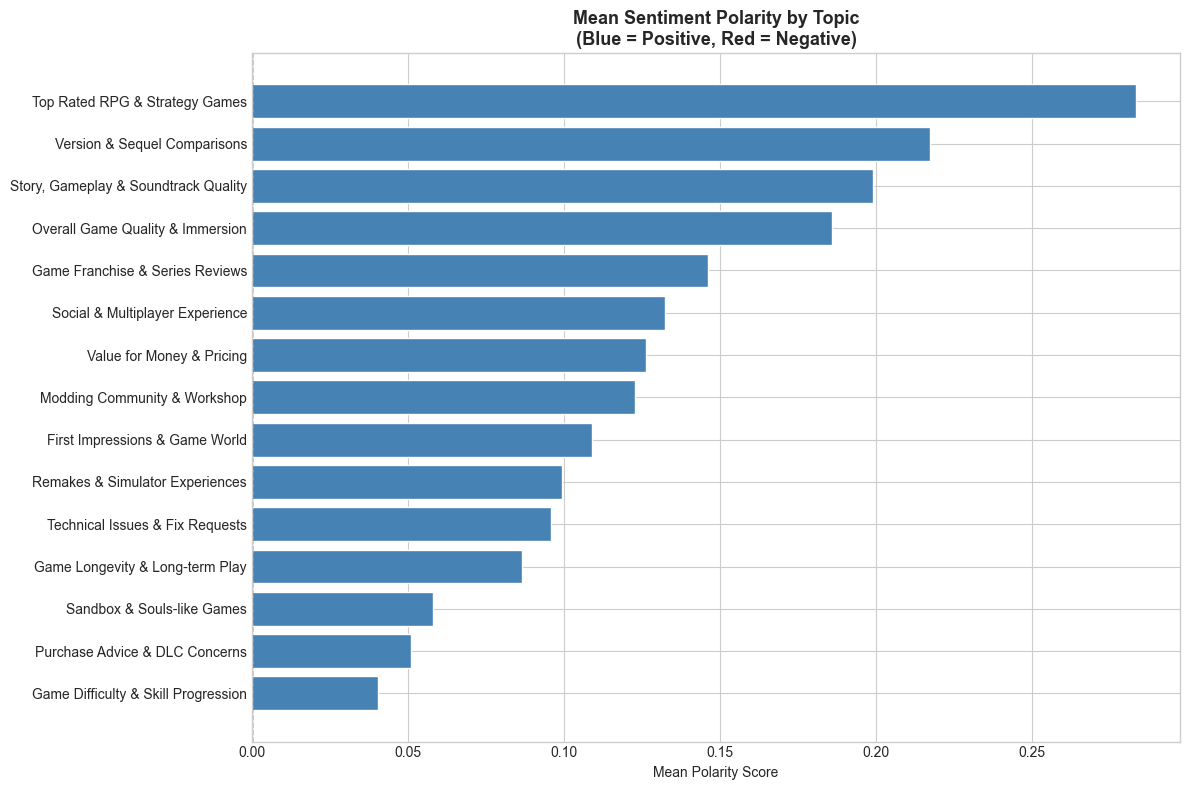

In [64]:
topic_sentiment = df.groupby('nmf_topic_label')['polarity']\
                    .mean().round(4)\
                    .sort_values(ascending=False)

print("Mean Polarity by Topic")
print(topic_sentiment)

fig, ax = plt.subplots(figsize=(12, 8))

colors = ['steelblue' if x > 0 else 'tomato' for x in topic_sentiment.values]

ax.barh(topic_sentiment.index, topic_sentiment.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=1, linestyle='--')
ax.set_title('Mean Sentiment Polarity by Topic\n'
             '(Blue = Positive, Red = Negative)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Polarity Score')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5.2 Helpfulness Prediction

We predict whether a review will be found helpful by the community using text features only.

**Target:** is_helpful
- 1 = Helpful (votes_helpful ≥ 1)
- 0 = Not Helpful (votes_helpful = 0)

**Class distribution:** 68% Not Helpful / 32% Helpful

We train two models:
- Logistic Regression: simple interpretable baseline
- Random Forest: captures non-linear patterns, provides feature importance scores

Both models use class_weight='balanced' to handle the
68/32 class imbalance.

### Build Text Feature Matrix

We build our feature matrix from text-derived features only:

1. **TF-IDF vectors**: converts review text into numerical word importance scores (5,000 most informative words)
2. **Text-derived numerical features**: word count, TTR, polarity, subjectivity, topic membership

All features are scaled using MaxAbsScaler which preserves sparsity while bringing all features to the same scale, critical for Logistic Regression convergence.

In [ ]:
# Handle missing values
for col in ['word_count_cleaned', 'ttr', 'lda_topic', 'nmf_topic']:
    df[col] = df[col].fillna(0)

print("Building TF-IDF matrix...")
tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.95
)
tfidf_matrix = tfidf.fit_transform(
    df['review_cleaned_sentiment'].fillna(''))
print(f"TF-IDF shape : {tfidf_matrix.shape}")

text_numerical = df[[
    'word_count_cleaned',  
    'ttr',                 
    'polarity',            
    'subjectivity',        
    'lda_topic',           
    'nmf_topic',           
]].astype(float).values

numerical_sparse  = csr_matrix(text_numerical)
combined          = hstack([tfidf_matrix, numerical_sparse])
scaler            = MaxAbsScaler()
combined_scaled   = scaler.fit_transform(combined)

print(f"Numerical features : {text_numerical.shape[1]}")
print(f"Total features     : {combined_scaled.shape[1]:,}")

Building TF-IDF matrix...
   TF-IDF shape : (919083, 5000)
Numerical features : 6
Total features     : 5,006


### Train/Test Split

We split 80% for training and 20% for testing using stratified sampling to preserve the 68/32 class ratio in both splits.

In [67]:
y = df['is_helpful'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    combined_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training samples : {X_train.shape[0]:,}")
print(f"Test samples     : {X_test.shape[0]:,}")

print(f"\nClass distribution in test set:")
dist = pd.Series(y_test).value_counts().sort_index()
pct  = pd.Series(y_test).value_counts(normalize=True).sort_index().mul(100).round(1)

print(pd.DataFrame({
    'count'  : dist.values,
    'percent': pct.values
}, index=['Not Helpful (0)', 'Helpful (1)']))

Training samples : 735,266
Test samples     : 183,817

Class distribution in test set:
                  count  percent
Not Helpful (0)  124696     67.8
Helpful (1)       59121     32.2


### Train Logistic Regression

Logistic Regression is our baseline model. It is simple, fast, and highly interpretable. Its coefficients tell us directly which words push a review toward helpful or not helpful.

We use `solver='liblinear'` which is specifically designed for high-dimensional sparse data like TF-IDF matrices.

In [68]:
print("Training Logistic Regression...")

lr = LogisticRegression(
    class_weight='balanced',
    solver='liblinear',
    max_iter=1000,
    random_state=42
)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression Results")
print(classification_report(y_test, y_pred_lr, target_names=['Not Helpful', 'Helpful']))
print(f"ROC-AUC : "f"{roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]):.4f}")

Training Logistic Regression...
Logistic Regression Results
              precision    recall  f1-score   support

 Not Helpful       0.76      0.67      0.71    124696
     Helpful       0.45      0.55      0.49     59121

    accuracy                           0.63    183817
   macro avg       0.60      0.61      0.60    183817
weighted avg       0.66      0.63      0.64    183817

ROC-AUC : 0.6540


### Train Random Forest

Random Forest is our primary model. It builds 200 decision trees and combines their predictions. It handles non-linear relationships that Logistic Regression cannot capture and provides feature importance scores that tell us exactly which linguistic patterns drive helpfulness.

In [69]:
print("Training Random Forest...")

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Results")
print(classification_report(y_test, y_pred_rf, target_names=['Not Helpful', 'Helpful']))
print(f"ROC-AUC : "f"{roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.4f}")

Training Random Forest...
Random Forest Results
              precision    recall  f1-score   support

 Not Helpful       0.71      0.89      0.79    124696
     Helpful       0.51      0.25      0.34     59121

    accuracy                           0.68    183817
   macro avg       0.61      0.57      0.56    183817
weighted avg       0.65      0.68      0.65    183817

ROC-AUC : 0.6249


### Compare Both Models

We compare Logistic Regression and Random Forest side by side. Since our dataset is imbalanced (68/32), we focus on:

- **Macro F1**: balanced performance across both classes
- **ROC-AUC**: overall ability to distinguish helpful from not helpful reviews
- **F1 Helpful**: how well we identify helpful reviews

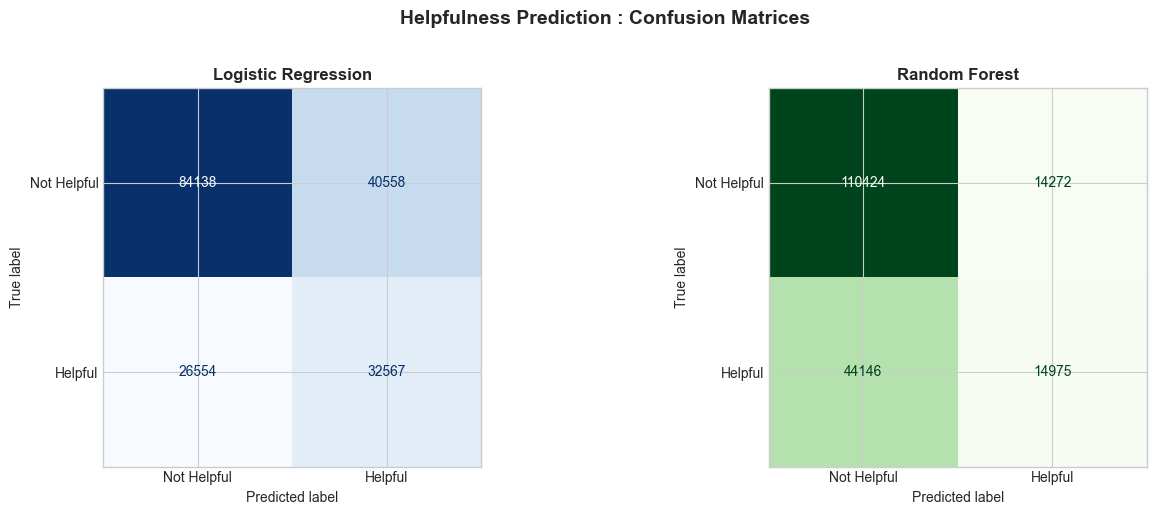

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr), display_labels=['Not Helpful', 'Helpful']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Logistic Regression', fontsize=12, fontweight='bold')

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf), display_labels=['Not Helpful', 'Helpful']).plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Random Forest', fontsize=12, fontweight='bold')

plt.suptitle('Helpfulness Prediction : Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [81]:
# Metrics summary
results = pd.DataFrame({
    'Model'       : ['Logistic Regression', 'Random Forest'],
    'Accuracy'    : [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)],
    'Macro F1'    : [
        f1_score(y_test, y_pred_lr, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro')],
    'F1 Helpful'  : [
        f1_score(y_test, y_pred_lr, pos_label=1),
        f1_score(y_test, y_pred_rf, pos_label=1)],
    'ROC-AUC'     : [
        roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])]
}).round(4)

print("Model Comparison")
print(results.to_string(index=False))

better = results.loc[results['Macro F1'].idxmax(), 'Model']
print(f"\nBetter model : {better}")

Model Comparison
              Model  Accuracy  Macro F1  F1 Helpful  ROC-AUC
Logistic Regression    0.6349    0.6037      0.4925   0.6540
      Random Forest    0.6822    0.5649      0.3389   0.6249

Better model : Logistic Regression


## 5.3 Linguistic Pattern Analysis

This section directly answers our core question:
**"What linguistic patterns make a review helpful?"**

We analyze three things:
1. Which specific WORDS appear most in helpful reviews
2. Which TEXT CHARACTERISTICS matter most (length, vocabulary, sentiment, topic)
3. Which TOPICS produce the most helpful reviews

### 5.3a Most Important Words

We extract the top 20 words that most strongly predict helpfulness from the Random Forest model.

High importance words appear disproportionately in helpful reviews, they represent the vocabulary of useful reviewers.

Top 20 Words Driving Helpfulness 
fun          0.010030
good         0.008251
not          0.006642
great        0.006377
like         0.006266
best         0.005117
love         0.004675
dont         0.004471
friend       0.004115
recommend    0.003746
amazing      0.003685
ever         0.003574
buy          0.003516
cant         0.002843
better       0.002839
story        0.002729
worth        0.002668
need         0.002492
awesome      0.002485
new          0.002436
dtype: float64


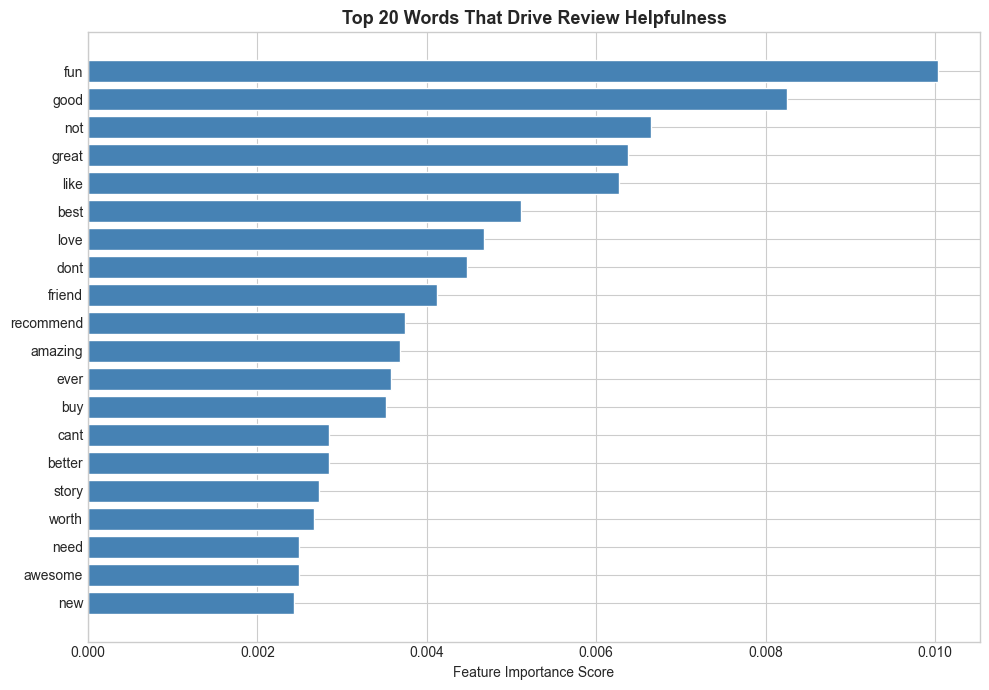

In [73]:
feature_names = (
    list(tfidf.get_feature_names_out()) +
    ['word_count', 'ttr', 'polarity',
     'subjectivity', 'lda_topic', 'nmf_topic']
)

importance = pd.Series(
    rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

top_words = importance[importance.index.isin(tfidf.get_feature_names_out())].head(20)

print("Top 20 Words Driving Helpfulness ")
print(top_words)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_words.index, top_words.values, color='steelblue', edgecolor='white')
ax.set_title('Top 20 Words That Drive Review Helpfulness', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Importance Score')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 5.3b Which Text Characteristics Matter Most?

Beyond individual words, we compare the importance of our text-derived features:

- **word_count**: does review length drive helpfulness?
- **ttr**: does vocabulary diversity matter?
- **polarity**: does sentiment strength matter?
- **subjectivity**: do opinionated reviews get more votes?
- **lda_topic / nmf_topic**: does topic matter?

This tells us whether it is what reviewers say (specific words) or how they write (length, style, sentiment) that the community values most.

Text Characteristic Importance
polarity        0.034957
word_count      0.028555
subjectivity    0.025333
lda_topic       0.015549
nmf_topic       0.010742
ttr             0.010270
dtype: float64


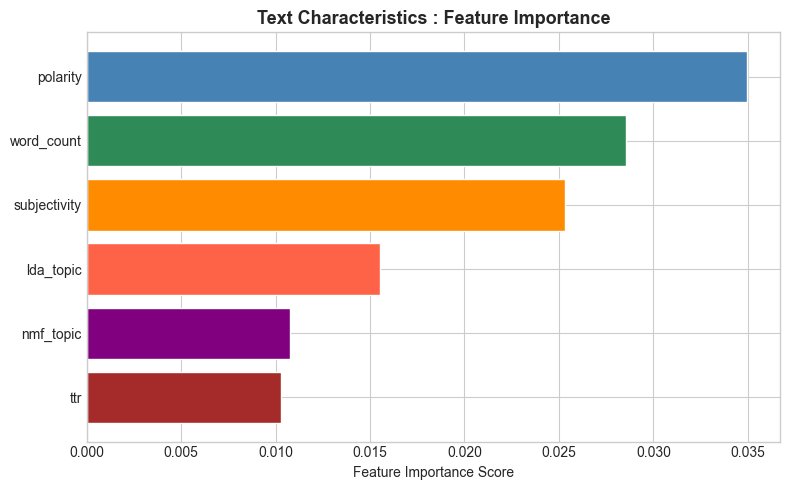

In [75]:
text_chars = importance[[
    'word_count', 'ttr', 'polarity',
    'subjectivity', 'lda_topic', 'nmf_topic'
]].sort_values(ascending=False)

print("Text Characteristic Importance")
print(text_chars)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(text_chars.index, text_chars.values, color=['steelblue', 'seagreen', 'darkorange','tomato', 'purple', 'brown'], edgecolor='white')
ax.set_title('Text Characteristics : Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Importance Score')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 5.3c Helpful vs Unhelpful Word Patterns

Logistic Regression coefficients give us signed importance scores, telling us not just which words matter but whether they push a review toward helpful or not helpful.

- **Positive coefficient**: word appears in helpful reviews
- **Negative coefficient**: word appears in unhelpful reviews

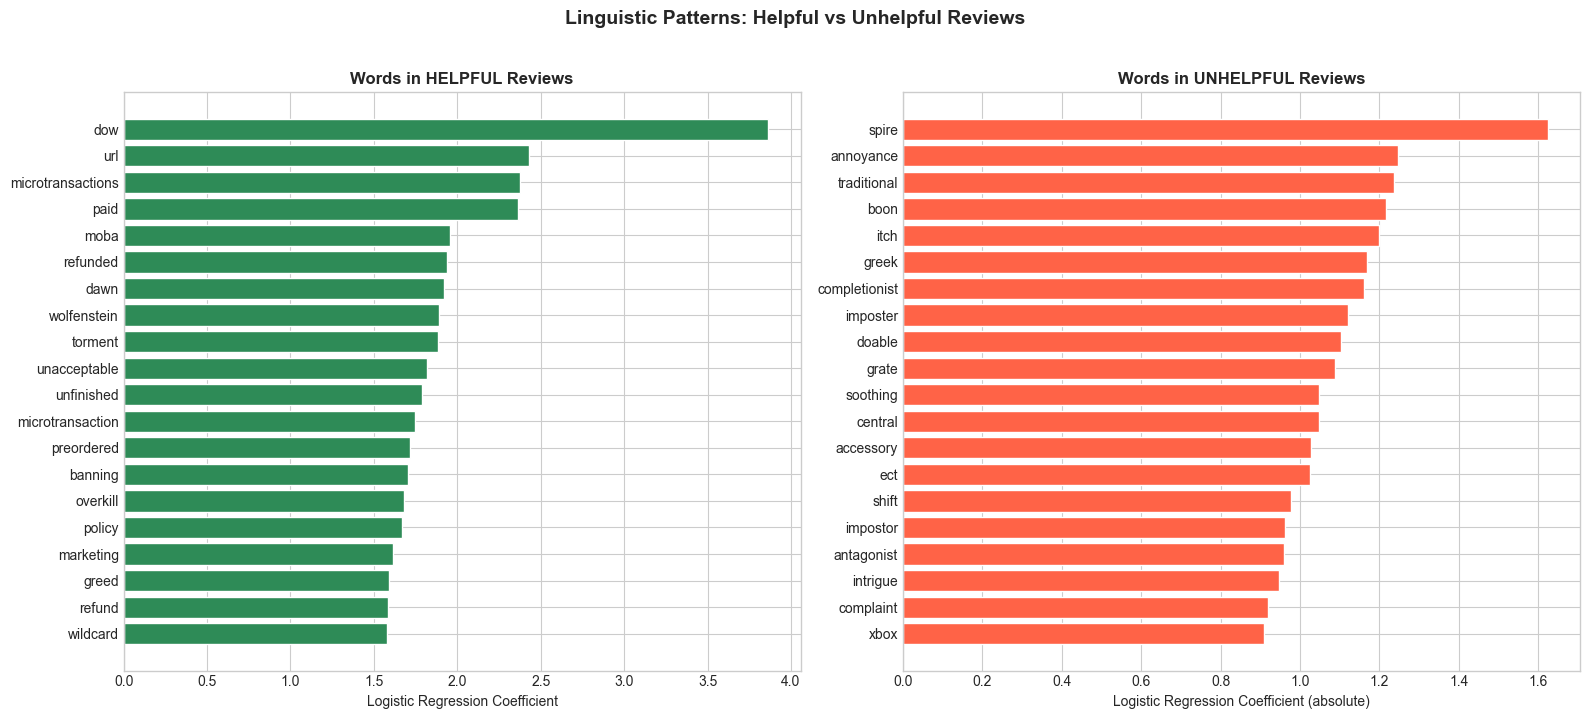

In [76]:
tfidf_vocab = tfidf.get_feature_names_out()
lr_coefs    = pd.Series(
    lr.coef_[0][:len(tfidf_vocab)],
    index=tfidf_vocab
)

top_helpful   = lr_coefs.nlargest(20)
top_unhelpful = lr_coefs.nsmallest(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(top_helpful.index, top_helpful.values, color='seagreen', edgecolor='white')
axes[0].set_title('Words in HELPFUL Reviews', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Logistic Regression Coefficient')
axes[0].invert_yaxis()

axes[1].barh(top_unhelpful.index, abs(top_unhelpful.values), color='tomato', edgecolor='white')
axes[1].set_title('Words in UNHELPFUL Reviews', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Logistic Regression Coefficient (absolute)')
axes[1].invert_yaxis()

plt.suptitle('Linguistic Patterns: Helpful vs Unhelpful Reviews', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.3d Which Topics Produce the Most Helpful Reviews?

We compute the percentage of helpful reviews per NMF topic. This reveals whether certain gaming themes consistently produce more community-valued reviews than others.

Topics with high helpfulness rates suggest that reviews about those themes tend to be detailed and informative. Topics with low rates suggest reviews tend to be short or emotional rather than informative.

Helpfulness Rate by Topic
                                      helpful_pct  review_count
nmf_topic_label                                                
Purchase Advice & DLC Concerns               39.4         30470
Game Longevity & Long-term Play              36.4         28865
Game Franchise & Series Reviews              35.6         24188
Technical Issues & Fix Requests              35.5         32111
Value for Money & Pricing                    35.2         36985
Remakes & Simulator Experiences              34.8         37023
Sandbox & Souls-like Games                   33.6         64598
Version & Sequel Comparisons                 33.4         28315
Modding Community & Workshop                 32.9         38341
First Impressions & Game World               31.1        417713
Story, Gameplay & Soundtrack Quality         31.0         38670
Overall Game Quality & Immersion             30.6         39094
Top Rated RPG & Strategy Games               30.1         33945
Game Difficult

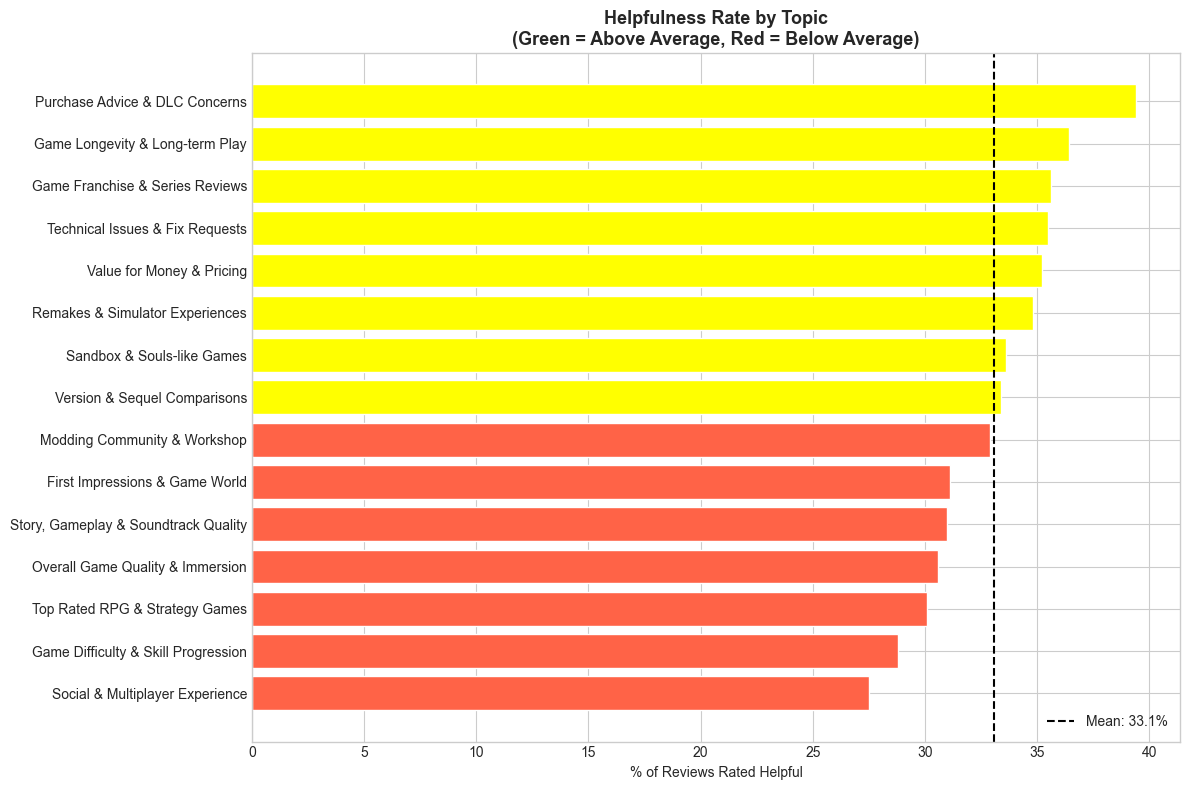

In [78]:
topic_help = df.groupby('nmf_topic_label').agg(
    helpful_pct  = ('is_helpful', 'mean'),
    review_count = ('review',     'count')
).round(4)
topic_help['helpful_pct'] = topic_help['helpful_pct'].mul(100).round(1)
topic_help = topic_help.sort_values('helpful_pct', ascending=False)

print("Helpfulness Rate by Topic")
print(topic_help)

mean_help = topic_help['helpful_pct'].mean()
colors    = ['yellow' if x > mean_help else 'tomato' for x in topic_help['helpful_pct']]

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(topic_help.index, topic_help['helpful_pct'], color=colors, edgecolor='white')
ax.axvline(mean_help, color='black', linestyle='--', linewidth=1.5, label=f'Mean: {mean_help:.1f}%')
ax.set_title('Helpfulness Rate by Topic\n' '(Green = Above Average, Red = Below Average)', fontsize=13, fontweight='bold')
ax.set_xlabel('% of Reviews Rated Helpful')
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

## 5.4 Text Feature Export

The final deliverable of our text mining branch is a clean set of text-derived features per review that we can join with behavioral features for the hybrid recommendation system.

**What we export:**

| Feature | What it captures |
|---|---|
| polarity | How positive or negative the review is |
| subjectivity | How opinionated the review is |
| word_count_cleaned | How long the review is |
| ttr | How diverse the vocabulary is |
| lda_topic | Topic number from LDA (0–9) |
| lda_topic_label | Topic name from LDA |
| nmf_topic | Topic number from NMF (0–14) |
| nmf_topic_label | Topic name from NMF |
| is_helpful | Whether community found review helpful |

These features capture topic preferences and sentiment patterns that complement behavioral features like playtime and purchase type in the hybrid model.

### Train/Test Split for Helpfulness Task

We use the same combined feature matrix but switch the target variable to `is_helpful`. Stratified splitting preserves the 68/32 class ratio in both splits.

In [79]:
export_cols = [
    'app_id',
    'app_name',
    'review_cleaned_sentiment',
    'polarity',
    'subjectivity',
    'word_count_cleaned',
    'ttr',
    'lda_topic',
    'lda_topic_label',
    'nmf_topic',
    'nmf_topic_label',
    'is_helpful',
    'votes_helpful',
    'recommended',
]

df_export = df[export_cols].copy()

print(f"Rows    : {len(df_export):,}")
print(f"Columns : {df_export.columns.tolist()}")
print(f"\nSample:")
print(df_export.head(3))

Rows    : 919,083
Columns : ['app_id', 'app_name', 'review_cleaned_sentiment', 'polarity', 'subjectivity', 'word_count_cleaned', 'ttr', 'lda_topic', 'lda_topic_label', 'nmf_topic', 'nmf_topic_label', 'is_helpful', 'votes_helpful', 'recommended']

Sample:
   app_id   app_name review_cleaned_sentiment  polarity  subjectivity  \
0      70  Half-Life    tower ridicoulous tie  0.000000      0.000000   
1      70  Half-Life                  try new  0.068182      0.227273   
2      70  Half-Life   ultimate fps ever hand -0.097222      0.644444   

   word_count_cleaned  ttr  lda_topic                    lda_topic_label  \
0                   3  1.0          6  Strategy, War & Modding Community   
1                   2  1.0          1    Game Updates & Value Assessment   
2                   4  1.0          8                FPS & Casual Gaming   

   nmf_topic                 nmf_topic_label  is_helpful  votes_helpful  \
0          0  First Impressions & Game World           0              0 

### Save All Outputs

We save two files:
1. Full dataset with all computed features
2. Export file with text-derived features for next phase.

In [80]:
# Full dataset
df.to_parquet('../data/steam_text_mining_nb5.parquet', index=False)

# Export for integration
df_export.to_parquet('../data/steam_text_features_export.parquet', index=False)

print(f"   File    : steam_text_mining_nb5.parquet")
print(f"   Rows    : {len(df):,}")
print(f"   Columns : {df.shape[1]}")

print(f"   File    : steam_text_features_export.parquet")
print(f"   Rows    : {len(df_export):,}")
print(f"   Columns : {df_export.shape[1]}")

   File    : steam_text_mining_nb5.parquet
   Rows    : 919,083
   Columns : 22
   File    : steam_text_features_export.parquet
   Rows    : 919,083
   Columns : 14


### Notebook 5 Summary

| Step | Detail |
|---|---|
| Reviews analyzed | 919,083 |
| Sentiment tool | TextBlob (polarity + subjectivity) |
| Helpfulness target | is_helpful (votes_helpful ≥ 1) |
| Text features used | TF-IDF (5,000 words) + 6 text-derived features |
| Better model | Logistic Regression |
| LR Macro F1 | 0.60 |
| LR ROC-AUC | 0.6540 |
| RF Macro F1 | 0.56 |
| RF ROC-AUC | 0.6249 |

**5.1 Sentiment Analysis:**

| | Positive Reviews | Negative Reviews |
|---|---|---|
| Mean Polarity | +0.1494 | −0.0829 |
| Mean Subjectivity | 0.4780 | 0.4624 |

Positive reviews show clearly higher polarity than negative reviews, confirming our preprocessing correctly preserved sentiment signals. The most positive topic was "Top Rated RPG & Strategy Games" (0.2832) while the least positive was "Game Difficulty & Skill Progression" (0.0405), players discussing challenging games tend to write more mixed reviews.

**5.2 Helpfulness Prediction:**

| Model | Accuracy | Macro F1 | F1 Helpful | ROC-AUC |
|---|---|---|---|---|
| Logistic Regression | 0.63 | 0.60 | 0.49 | 0.6540 |
| Random Forest | 0.68 | 0.56 | 0.34 | 0.6249 |

Logistic Regression outperformed Random Forest on all key metrics. This is expected, TF-IDF features are sparse and high dimensional, which naturally favors linear models over tree-based ensemble methods.

**5.3 Linguistic Findings:**

| Finding | Result |
|---|---|
| Top helpful words | fun, good, not, great, like |
| Most important text feature | polarity (0.035) |
| Second most important | word_count (0.029) |
| Most helpful topic | Purchase Advice & DLC (39.4%) |
| Least helpful topic | Social & Multiplayer (27.5%) |

**Key Observations:**

1. **Sentiment is the Strongest Signal:** Polarity was the single most important text feature (0.035), followed by word count (0.029) and subjectivity (0.025). This confirms that HOW a review is written, its emotional tone and length matters more to the community than any single specific word.

2. **Review Length Matters:** word_count ranked second in importance, consistent with our Chapter 3 finding that helpful reviews are nearly twice as long on average (mean 30 vs 16 words). Longer reviews provide more detail and are valued more by the community.

3. **Topic Drives Helpfulness:** Reviews about "Purchase Advice & DLC Concerns" had the highest helpfulness rate (39.4%), while "Social & Multiplayer Experience" had the lowest (27.5%). The community most values reviews that help them make purchasing decisions.

4. **Moderate Prediction Performance is Expected:** Both models achieved ROC-AUC around 0.62–0.65 using text features only. This moderate performance reflects that helpfulness also depends on non-textual factors such as review timing, game popularity, and community visibility, factors text mining alone cannot capture. This directly motivates the integration with behavioral features in the hybrid model.

5. **Text Features Ready for Integration:** polarity, subjectivity, word_count, ttr, topic assignments, and helpfulness labels are exported as a clean feature set joinable on app_id with behavioral features for the hybrid recommendation system.

**Output:** `steam_text_mining_nb5.parquet`
**Export:** `steam_text_features_export.parquet`